In [ ]:
!pip install -q gradio xgboost --upgrade

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving Road_Accident_Dataset.csv to Road_Accident_Dataset.csv


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import joblib
import warnings

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                              confusion_matrix, roc_curve, auc)

warnings.filterwarnings("ignore")
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)
np.random.seed(42)

print("✅ Libraries imported successfully.")

✅ Libraries imported successfully.


In [ ]:
filename = next(iter(uploaded))
df = pd.read_csv(filename)

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (6000, 23)


,Road_Type,Weather,Visibility_km,Road_Surface,Light_Condition,Vehicle_Speed,Traffic_Density,Vehicle_Type,Driver_Age,Driver_Experience,...,Day_of_Week,Area_Type,Road_Curvature,Junction_Type,Traffic_Signal,Pedestrian_Crossing,Rain,Fog,Temperature_C,Accident_Occurred
0,Rural Road,Foggy,9.2,Dry,Dark - Lit,116.0,Low,Truck,50,9,...,Sunday,Urban,Sharp Curve,Crossroad,No,No,No,No,27.3,1
1,Residential,Snowy,5.3,Wet,Dark - Lit,85.5,High,Bus,58,0,...,Saturday,Rural,Straight,No Junction,No,No,No,No,10.8,1
2,Highway,Clear,7.3,Wet,Dark - Unlit,27.8,Medium,Bus,57,31,...,Wednesday,Rural,Slight Curve,T-Junction,No,No,Yes,No,17.4,0
3,Rural Road,Rainy,4.5,Dry,Dusk/Dawn,148.6,Low,Motorcycle,18,31,...,Thursday,Rural,Straight,Crossroad,Yes,No,Yes,No,27.3,1
4,Rural Road,Rainy,6.4,Dry,Dusk/Dawn,157.2,Medium,Car,59,26,...,Sunday,Rural,Straight,Roundabout,No,Yes,No,No,19.0,1


In [ ]:
print("Missing values:\n", df.isnull().sum().sum())
print("\nDuplicate rows:", df.duplicated().sum())
print("\nTarget class distribution:")
print(df["Accident_Occurred"].value_counts())
df.describe(include="all").T

Missing values:
 0

Duplicate rows: 0

Target class distribution:
Accident_Occurred
0    3113
1    2887
Name: count, dtype: int64


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Road_Type,6000,4,Highway,1562,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Weather,6000,5,Clear,2795,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Visibility_km,6000.0,NaN,NaN,NaN,5.105733,2.835636,0.2,2.7,5.1,7.6,10.0
Road_Surface,6000,4,Dry,3241,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Light_Condition,6000,4,Daylight,1622,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Vehicle_Speed,6000.0,NaN,NaN,NaN,88.9271,39.910818,20.0,54.6,89.05,122.425,160.0
Traffic_Density,6000,3,Medium,2096,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Vehicle_Type,6000,4,Truck,1524,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Driver_Age,6000.0,NaN,NaN,NaN,46.0605,16.434766,18.0,32.0,46.0,60.0,74.0
Driver_Experience,6000.0,NaN,NaN,NaN,19.428667,11.639995,0.0,9.0,20.0,29.0,39.0


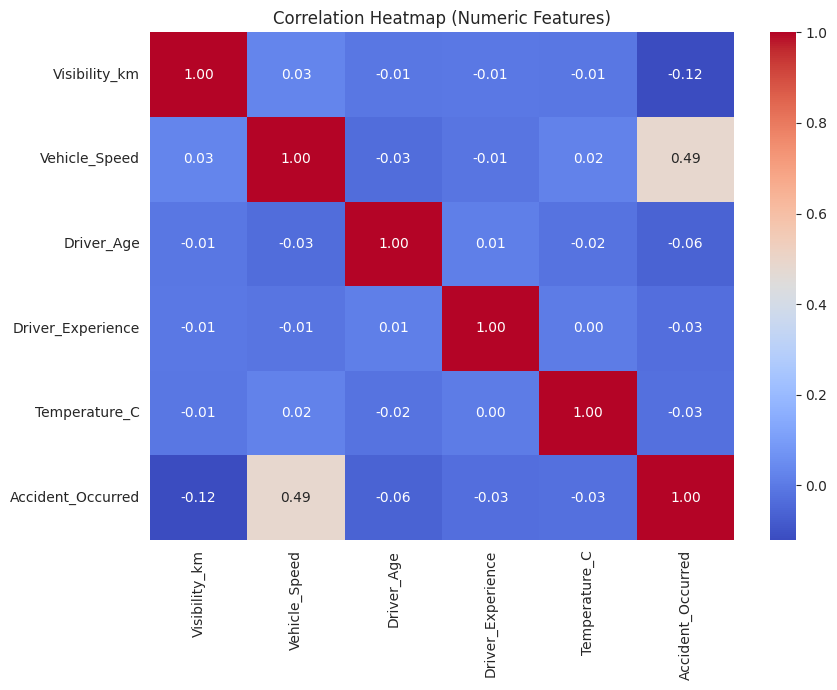

In [ ]:
plt.figure(figsize=(9, 7))
numeric_df = df.select_dtypes(include=[np.number])
sns.heatmap(numeric_df.corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Heatmap (Numeric Features)")
plt.tight_layout()
plt.show()

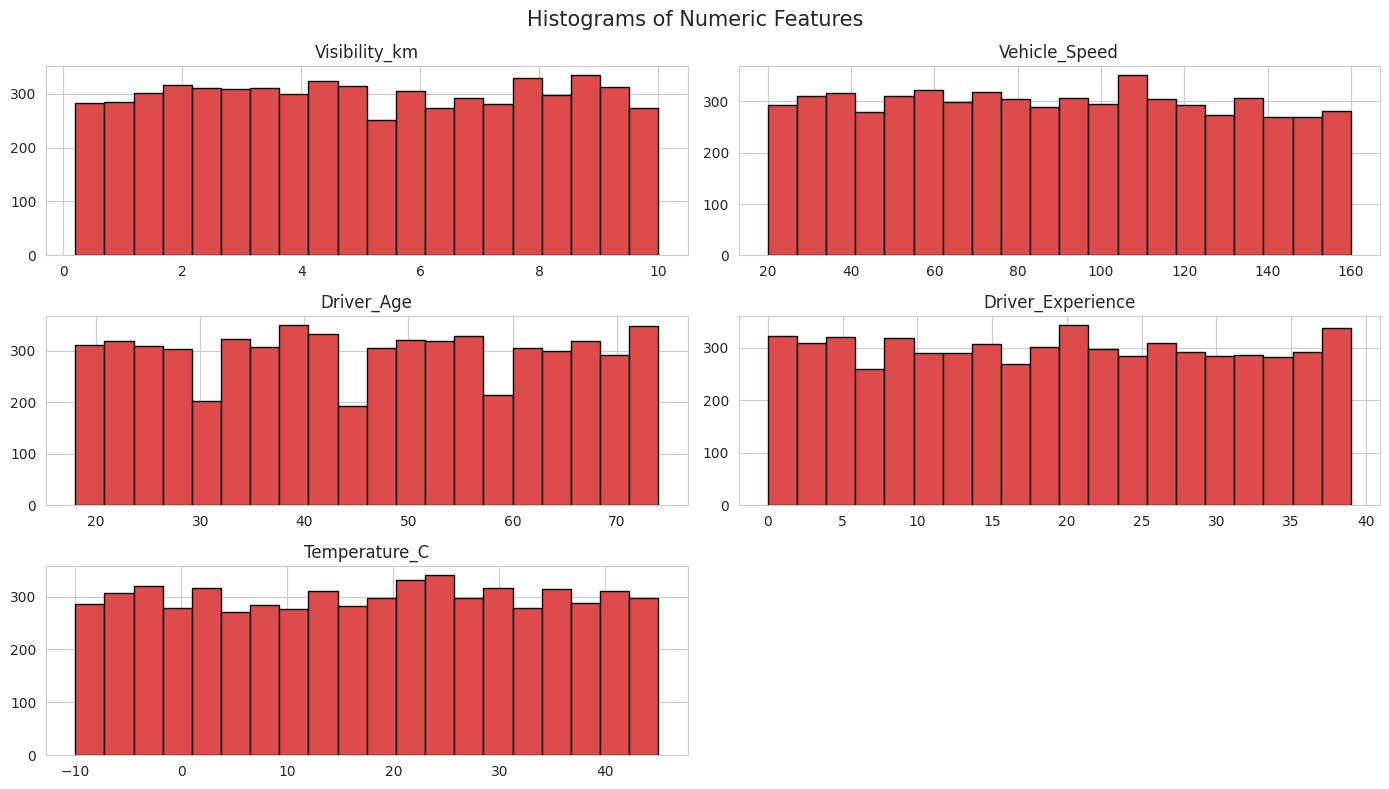

In [ ]:
df[["Visibility_km", "Vehicle_Speed", "Driver_Age", "Driver_Experience", "Temperature_C"]].hist(
    bins=20, figsize=(14, 8), color="#DD4B4B", edgecolor="black")
plt.suptitle("Histograms of Numeric Features", fontsize=15)
plt.tight_layout()
plt.show()

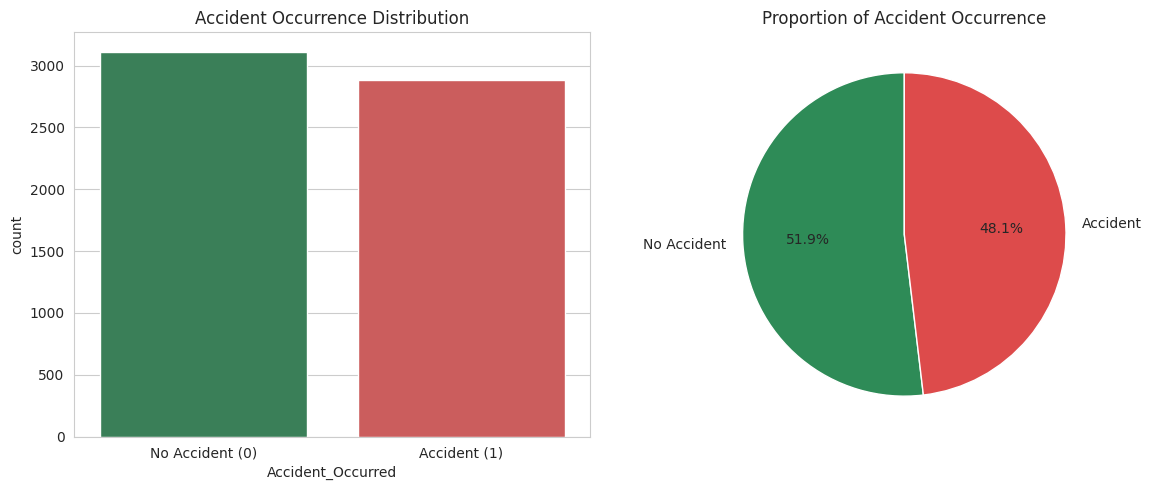

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.countplot(x="Accident_Occurred", data=df, palette=["#2E8B57", "#DD4B4B"], ax=axes[0])
axes[0].set_xticklabels(["No Accident (0)", "Accident (1)"])
axes[0].set_title("Accident Occurrence Distribution")

df["Accident_Occurred"].value_counts().plot.pie(
    labels=["No Accident", "Accident"], autopct="%1.1f%%",
    colors=["#2E8B57", "#DD4B4B"], startangle=90, ax=axes[1])
axes[1].set_title("Proportion of Accident Occurrence")
axes[1].set_ylabel("")

plt.tight_layout()
plt.show()

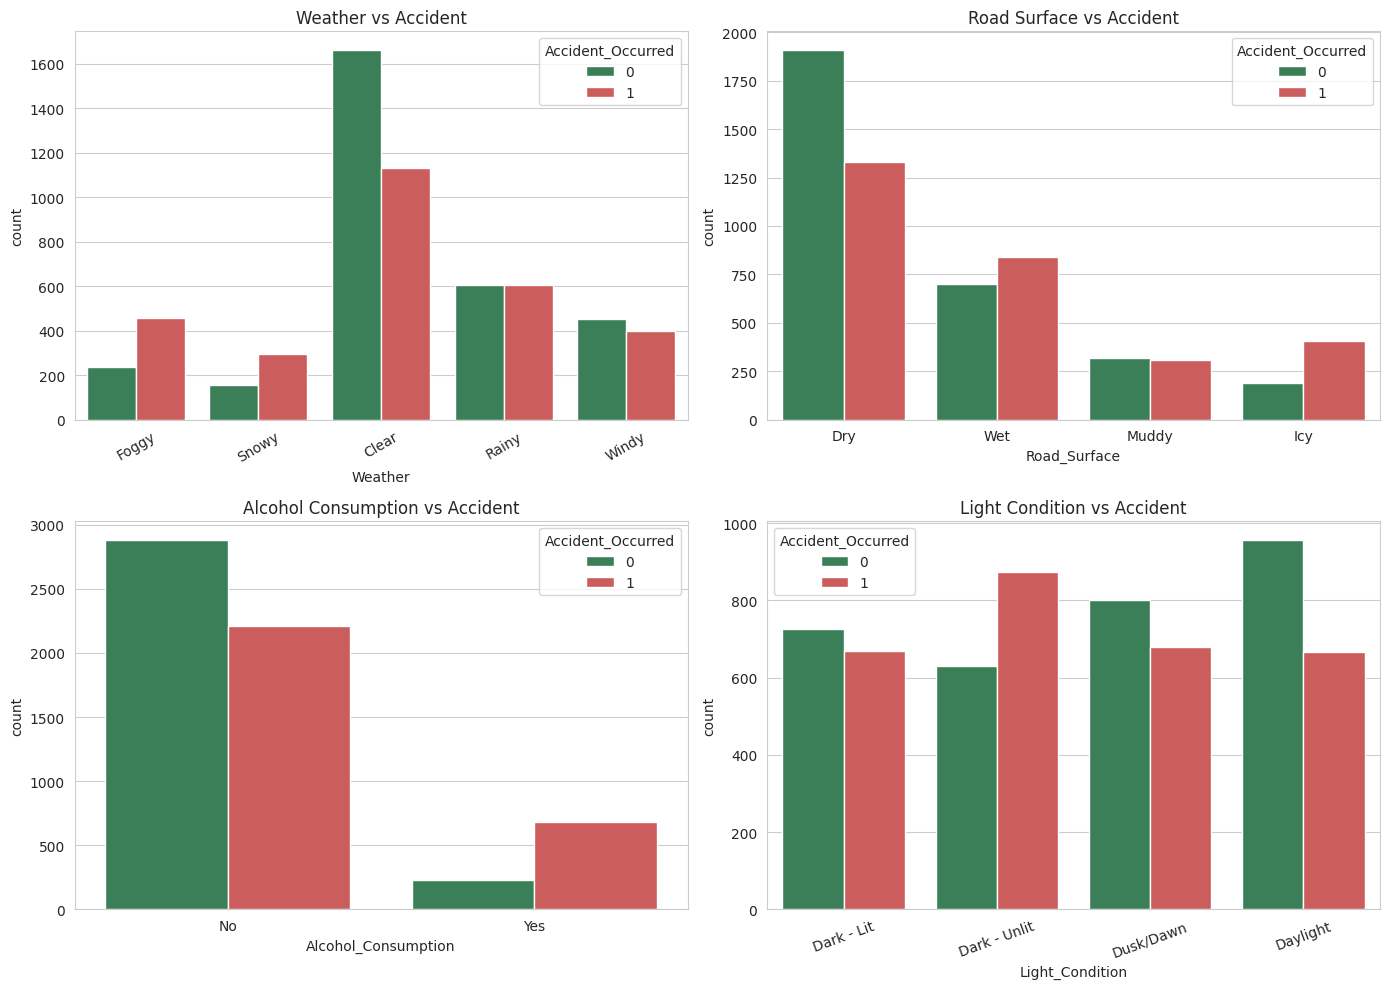

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
sns.countplot(x="Weather", hue="Accident_Occurred", data=df, ax=axes[0, 0], palette=["#2E8B57", "#DD4B4B"])
axes[0, 0].set_title("Weather vs Accident")
axes[0, 0].tick_params(axis="x", rotation=30)

sns.countplot(x="Road_Surface", hue="Accident_Occurred", data=df, ax=axes[0, 1], palette=["#2E8B57", "#DD4B4B"])
axes[0, 1].set_title("Road Surface vs Accident")

sns.countplot(x="Alcohol_Consumption", hue="Accident_Occurred", data=df, ax=axes[1, 0], palette=["#2E8B57", "#DD4B4B"])
axes[1, 0].set_title("Alcohol Consumption vs Accident")

sns.countplot(x="Light_Condition", hue="Accident_Occurred", data=df, ax=axes[1, 1], palette=["#2E8B57", "#DD4B4B"])
axes[1, 1].set_title("Light Condition vs Accident")
axes[1, 1].tick_params(axis="x", rotation=20)

plt.tight_layout()
plt.show()

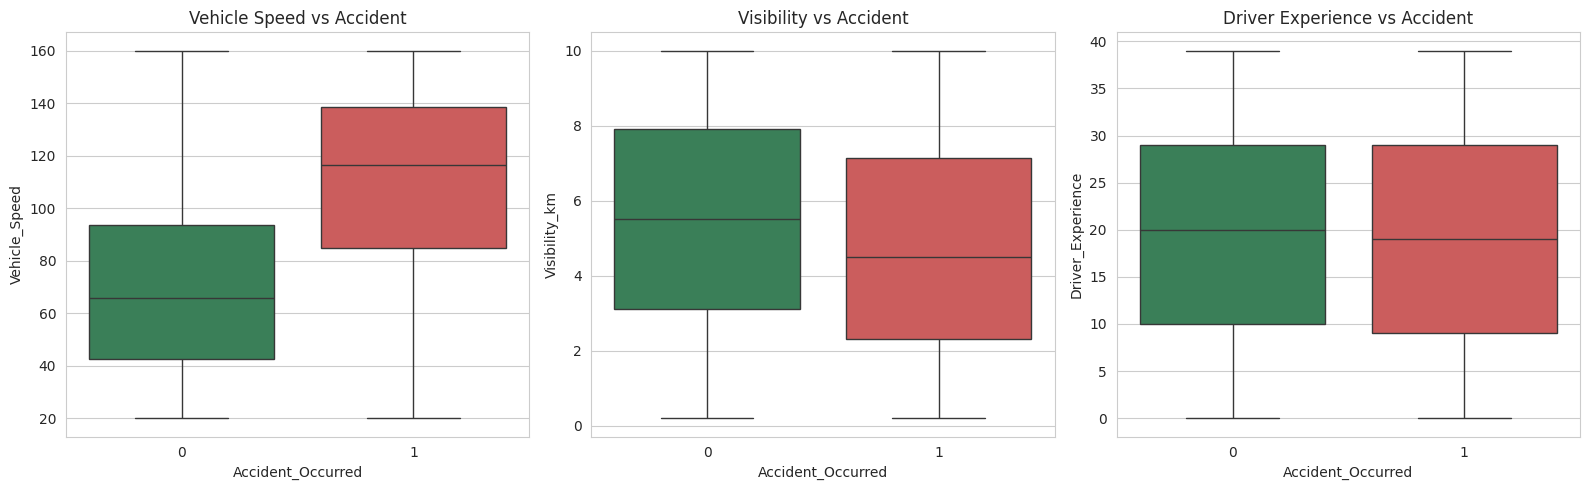

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
sns.boxplot(x="Accident_Occurred", y="Vehicle_Speed", data=df, ax=axes[0], palette=["#2E8B57", "#DD4B4B"])
axes[0].set_title("Vehicle Speed vs Accident")

sns.boxplot(x="Accident_Occurred", y="Visibility_km", data=df, ax=axes[1], palette=["#2E8B57", "#DD4B4B"])
axes[1].set_title("Visibility vs Accident")

sns.boxplot(x="Accident_Occurred", y="Driver_Experience", data=df, ax=axes[2], palette=["#2E8B57", "#DD4B4B"])
axes[2].set_title("Driver Experience vs Accident")

plt.tight_layout()
plt.show()

In [ ]:
df_processed = df.copy()

df_processed = df_processed.fillna(df_processed.mode().iloc[0])

before = df_processed.shape[0]
df_processed = df_processed.drop_duplicates()
print(f"Removed {before - df_processed.shape[0]} duplicate rows.")

categorical_cols = [
    "Road_Type", "Weather", "Road_Surface", "Light_Condition", "Traffic_Density",
    "Vehicle_Type", "Time_of_Day", "Day_of_Week", "Area_Type", "Road_Curvature",
    "Junction_Type", "Traffic_Signal", "Pedestrian_Crossing", "Rain", "Fog",
    "Alcohol_Consumption", "Seat_Belt"
]
numerical_cols = ["Visibility_km", "Vehicle_Speed", "Driver_Age", "Driver_Experience", "Temperature_C"]

label_encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    df_processed[col] = le.fit_transform(df_processed[col])
    label_encoders[col] = le

print("✅ Categorical encoding complete.")
df_processed.head()

Removed 0 duplicate rows.
✅ Categorical encoding complete.


,Road_Type,Weather,Visibility_km,Road_Surface,Light_Condition,Vehicle_Speed,Traffic_Density,Vehicle_Type,Driver_Age,Driver_Experience,...,Day_of_Week,Area_Type,Road_Curvature,Junction_Type,Traffic_Signal,Pedestrian_Crossing,Rain,Fog,Temperature_C,Accident_Occurred
0,2,1,9.2,0,0,116.0,1,3,50,9,...,3,1,0,0,0,0,0,0,27.3,1
1,1,3,5.3,3,0,85.5,0,0,58,0,...,2,0,2,1,0,0,0,0,10.8,1
2,0,0,7.3,3,1,27.8,2,0,57,31,...,6,0,1,3,0,0,1,0,17.4,0
3,2,2,4.5,0,3,148.6,1,2,18,31,...,4,0,2,0,1,0,1,0,27.3,1
4,2,2,6.4,0,3,157.2,2,1,59,26,...,3,0,2,2,0,1,0,0,19.0,1


In [ ]:
for col in numerical_cols:
    Q1 = df_processed[col].quantile(0.25)
    Q3 = df_processed[col].quantile(0.75)
    IQR = Q3 - Q1
    lower, upper = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
    df_processed[col] = np.clip(df_processed[col], lower, upper)

print("✅ Outlier capping applied to numeric columns.")

✅ Outlier capping applied to numeric columns.


In [ ]:
df_processed["Speed_Over_Limit"] = np.clip(df_processed["Vehicle_Speed"] - 60, 0, None)
df_processed["Experience_Ratio"] = df_processed["Driver_Experience"] / (df_processed["Driver_Age"] - 15)
df_processed["Low_Visibility_Flag"] = (
    (df["Visibility_km"] < 3) | (df["Fog"] == "Yes") |
    (df["Light_Condition"].isin(["Dark - Unlit", "Dark - Lit"]))
).astype(int)

engineered_cols = ["Speed_Over_Limit", "Experience_Ratio", "Low_Visibility_Flag"]
all_feature_cols = categorical_cols + numerical_cols + engineered_cols

X = df_processed[all_feature_cols]
y = df_processed["Accident_Occurred"]

scaler = StandardScaler()
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("✅ Feature engineering complete.")
print("Final feature set:", all_feature_cols)
print("Train shape:", X_train.shape, " Test shape:", X_test.shape)

✅ Feature engineering complete.
Final feature set: ['Road_Type', 'Weather', 'Road_Surface', 'Light_Condition', 'Traffic_Density', 'Vehicle_Type', 'Time_of_Day', 'Day_of_Week', 'Area_Type', 'Road_Curvature', 'Junction_Type', 'Traffic_Signal', 'Pedestrian_Crossing', 'Rain', 'Fog', 'Alcohol_Consumption', 'Seat_Belt', 'Visibility_km', 'Vehicle_Speed', 'Driver_Age', 'Driver_Experience', 'Temperature_C', 'Speed_Over_Limit', 'Experience_Ratio', 'Low_Visibility_Flag']
Train shape: (4800, 25)  Test shape: (1200, 25)


In [ ]:
models = {
    "XGBoost": XGBClassifier(eval_metric="logloss", random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42),
    "KNN": KNeighborsClassifier(n_neighbors=7)
}

results = {}

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    y_proba = model.predict_proba(X_test_scaled)[:, 1]

    results[name] = {
        "model": model,
        "accuracy": accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred),
        "recall": recall_score(y_test, y_pred),
        "f1": f1_score(y_test, y_pred),
        "y_pred": y_pred,
        "y_proba": y_proba
    }
    print(f"✅ {name} trained — Accuracy: {results[name]['accuracy']:.4f}, F1: {results[name]['f1']:.4f}")

✅ XGBoost trained — Accuracy: 0.7833, F1: 0.7687
✅ Gradient Boosting trained — Accuracy: 0.7975, F1: 0.7817
✅ KNN trained — Accuracy: 0.7242, F1: 0.6868


In [ ]:
comparison_df = pd.DataFrame({
    name: {
        "Accuracy": res["accuracy"],
        "Precision": res["precision"],
        "Recall": res["recall"],
        "F1 Score": res["f1"]
    } for name, res in results.items()
}).T.sort_values("F1 Score", ascending=False)

comparison_df

,Accuracy,Precision,Recall,F1 Score
Gradient Boosting,0.797500,0.811567,0.753899,0.781671
XGBoost,0.783333,0.789762,0.748700,0.768683
KNN,0.724167,0.756250,0.629116,0.686850


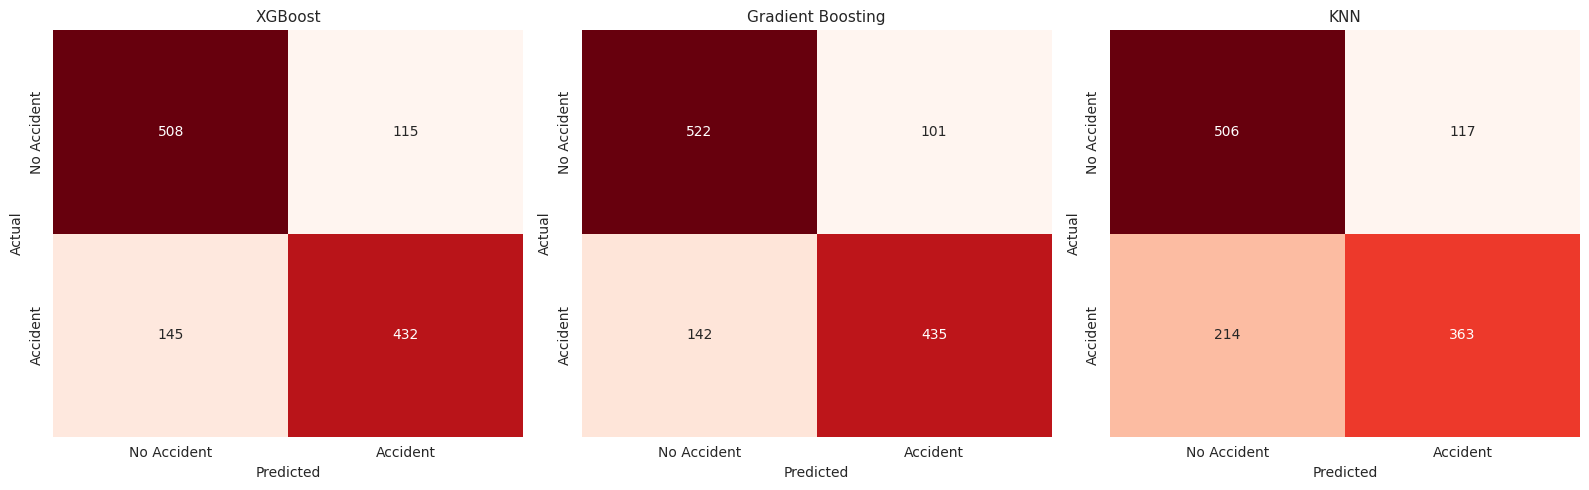

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, (name, res) in zip(axes, results.items()):
    cm = confusion_matrix(y_test, res["y_pred"])
    sns.heatmap(cm, annot=True, fmt="d", cmap="Reds", ax=ax, cbar=False,
                xticklabels=["No Accident", "Accident"], yticklabels=["No Accident", "Accident"])
    ax.set_title(name, fontsize=11)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
plt.tight_layout()
plt.show()

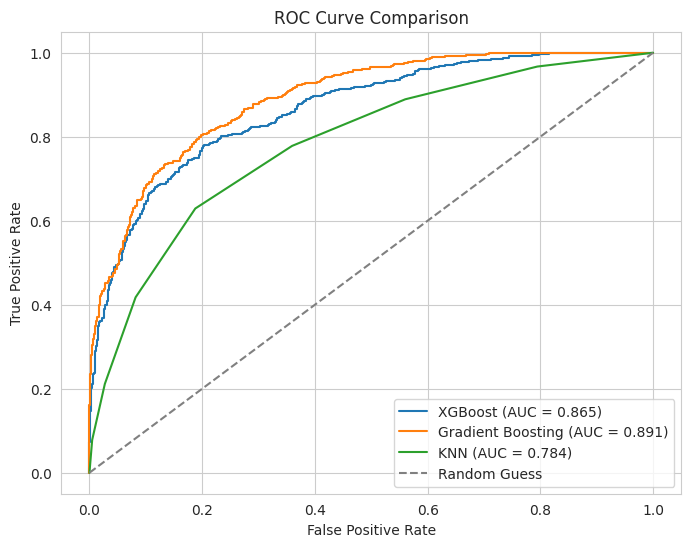

In [ ]:
plt.figure(figsize=(8, 6))
for name, res in results.items():
    fpr, tpr, _ = roc_curve(y_test, res["y_proba"])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{name} (AUC = {roc_auc:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Random Guess")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend(loc="lower right")
plt.show()

In [ ]:
print("5-Fold Cross-Validation Accuracy:")
for name, model in models.items():
    scores = cross_val_score(model, X_train_scaled, y_train, cv=5, scoring="accuracy")
    print(f"{name}: mean={scores.mean():.4f}, std={scores.std():.4f}")

5-Fold Cross-Validation Accuracy:
XGBoost: mean=0.7863, std=0.0084
Gradient Boosting: mean=0.8010, std=0.0089
KNN: mean=0.7227, std=0.0144


In [ ]:
with open("scaler.pkl", "wb") as f:
    pickle.dump(scaler, f)

with open("label_encoders.pkl", "wb") as f:
    pickle.dump(label_encoders, f)

saved_models = {name: results[name]["model"] for name in models.keys()}

with open("all_models.pkl", "wb") as f:
    pickle.dump(saved_models, f)

model_accuracies = {name: results[name]["accuracy"] for name in models.keys()}

metadata = {
    "feature_cols": all_feature_cols,
    "categorical_cols": categorical_cols,
    "numerical_cols": numerical_cols,
    "model_accuracies": model_accuracies
}
with open("model_metadata.pkl", "wb") as f:
    pickle.dump(metadata, f)

print("✅ All 3 models saved with their accuracies:")
print(model_accuracies)

✅ All 3 models saved with their accuracies:
{'XGBoost': 0.7833333333333333, 'Gradient Boosting': 0.7975, 'KNN': 0.7241666666666666}


In [ ]:
with open("scaler.pkl", "rb") as f:
    loaded_scaler = pickle.load(f)

with open("label_encoders.pkl", "rb") as f:
    loaded_encoders = pickle.load(f)

with open("all_models.pkl", "rb") as f:
    loaded_models = pickle.load(f)

with open("model_metadata.pkl", "rb") as f:
    loaded_metadata = pickle.load(f)

print("✅ Reloaded. Available models:", list(loaded_models.keys()))
print("Accuracies:", loaded_metadata["model_accuracies"])

✅ Reloaded. Available models: ['XGBoost', 'Gradient Boosting', 'KNN']
Accuracies: {'XGBoost': 0.7833333333333333, 'Gradient Boosting': 0.7975, 'KNN': 0.7241666666666666}


In [ ]:
import math

def build_needle_gauge(accuracy_percent, model_choice):
    pct = round(accuracy_percent, 1)
    angle_deg = 180 - (pct / 100 * 180)
    angle_rad = math.radians(angle_deg)

    cx, cy = 160, 165
    needle_length = 95
    tip_x = cx + needle_length * math.cos(angle_rad)
    tip_y = cy - needle_length * math.sin(angle_rad)

    def scale_point(value, radius):
        a = math.radians(180 - (value / 100 * 180))
        return cx + radius * math.cos(a), cy - radius * math.sin(a)

    scale_labels = ""
    for val in [0, 25, 50, 75, 100]:
        lx, ly = scale_point(val, 168)
        scale_labels += f'<text x="{lx:.1f}" y="{ly:.1f}" font-size="13" fill="#555" text-anchor="middle" font-family="sans-serif">{val}</text>'

    gauge_html = f"""
    <div style="display:flex; justify-content:center; align-items:center; width:100%; padding:10px 0;">
        <div style="text-align:center; font-family:'Segoe UI', sans-serif; background:white;
                    border-radius:24px; padding:20px 30px 18px 30px; box-shadow:0 10px 30px rgba(0,0,0,0.18);
                    display:inline-block;">
            <svg width="340" height="200" viewBox="0 0 340 200">
                <path d="M 35 165 A 125 125 0 0 1 91 58"  fill="none" stroke="#E53935" stroke-width="30"/>
                <path d="M 95 55 A 125 125 0 0 1 156 36"  fill="none" stroke="#F9C400" stroke-width="30"/>
                <path d="M 160 36 A 125 125 0 0 1 221 55" fill="none" stroke="#9CCC65" stroke-width="30"/>
                <path d="M 225 58 A 125 125 0 0 1 285 165" fill="none" stroke="#2E7D32" stroke-width="30"/>

                {scale_labels}

                <line x1="{cx}" y1="{cy}" x2="{tip_x:.1f}" y2="{tip_y:.1f}"
                      stroke="#2b2b2b" stroke-width="6" stroke-linecap="round"/>
                <circle cx="{cx}" cy="{cy}" r="13" fill="#2b2b2b" stroke="white" stroke-width="3"/>
            </svg>

            <div style="margin-top:6px;">
                <span style="font-size:20px; font-weight:600; color:#2C3E70;">Accuracy: {pct}%</span>
            </div>
            <p style="margin:4px 0 0 0; color:#888; font-size:13px;">
                Model — {model_choice}
            </p>
        </div>
    </div>
    """
    return gauge_html


def safe_label_encode(column_name, value):
    le = loaded_encoders[column_name]
    if value in le.classes_:
        return le.transform([value])[0]
    return le.transform([le.classes_[0]])[0]


def build_recommendation(risk_level, alcohol, seat_belt, speed, visibility):
    tips = []
    if alcohol == "Yes":
        tips.append("avoid driving under the influence of alcohol")
    if seat_belt == "No":
        tips.append("always wear a seat belt")
    if speed > 90:
        tips.append("reduce your speed")
    if visibility < 3:
        tips.append("use fog lights and slow down in low visibility")
    if not tips:
        tips.append("maintain safe speed and stay alert")

    prefix = {
        "High": "⚠️ High risk detected — please ",
        "Medium": "⚠️ Moderate risk — consider to ",
        "Low": "✅ Low risk, but always "
    }[risk_level]
    return prefix + ", ".join(tips) + "."


def predict_accident(model_choice, road_type, weather, visibility, road_surface, light_condition,
                      vehicle_speed, traffic_density, vehicle_type, driver_age,
                      driver_experience, alcohol, seat_belt, time_of_day, day_of_week,
                      area_type, road_curvature, junction_type, traffic_signal,
                      pedestrian_crossing, rain, fog, temperature):

    selected_model = loaded_models[model_choice]
    model_accuracy = loaded_metadata["model_accuracies"][model_choice]

    raw_input = {
        "Road_Type": road_type, "Weather": weather, "Road_Surface": road_surface,
        "Light_Condition": light_condition, "Traffic_Density": traffic_density,
        "Vehicle_Type": vehicle_type, "Time_of_Day": time_of_day, "Day_of_Week": day_of_week,
        "Area_Type": area_type, "Road_Curvature": road_curvature, "Junction_Type": junction_type,
        "Traffic_Signal": traffic_signal, "Pedestrian_Crossing": pedestrian_crossing,
        "Rain": rain, "Fog": fog, "Alcohol_Consumption": alcohol, "Seat_Belt": seat_belt
    }

    encoded = {col: safe_label_encode(col, val) for col, val in raw_input.items()}

    encoded["Visibility_km"] = visibility
    encoded["Vehicle_Speed"] = vehicle_speed
    encoded["Driver_Age"] = driver_age
    encoded["Driver_Experience"] = driver_experience
    encoded["Temperature_C"] = temperature

    encoded["Speed_Over_Limit"] = max(vehicle_speed - 60, 0)
    encoded["Experience_Ratio"] = driver_experience / max(driver_age - 15, 1)
    encoded["Low_Visibility_Flag"] = int(
        (visibility < 3) or (fog == "Yes") or (light_condition in ["Dark - Unlit", "Dark - Lit"])
    )

    input_df = pd.DataFrame([encoded])[loaded_metadata["feature_cols"]]
    input_scaled = loaded_scaler.transform(input_df)

    prediction = selected_model.predict(input_scaled)[0]
    probabilities = selected_model.predict_proba(input_scaled)[0]
    confidence = probabilities[prediction] * 100
    accident_probability = probabilities[1] * 100

    if accident_probability >= 70:
        risk_level = "High"
    elif accident_probability >= 40:
        risk_level = "Medium"
    else:
        risk_level = "Low"

    prediction_label = "🚦 High Risk of Road Accident" if prediction == 1 else "🟢 Low Risk — No Accident Likely"
    recommendation = build_recommendation(risk_level, alcohol, seat_belt, vehicle_speed, visibility)
    prob_text = f"No Accident: {probabilities[0]*100:.1f}%  |  Accident: {probabilities[1]*100:.1f}%"
    gauge_html = build_needle_gauge(model_accuracy * 100, model_choice)

    return prediction_label, f"{confidence:.1f}%", prob_text, risk_level, recommendation, gauge_html


print("✅ Prediction function ready.")

✅ Prediction function ready.


In [ ]:
import gradio as gr

custom_css = """
.gradio-container {
    background: linear-gradient(-45deg, #7f1d1d, #B22222, #FF6B6B, #FF9E5E, #7f1d1d);
    background-size: 400% 400%;
    animation: gradientMove 15s ease infinite;
}
@keyframes gradientMove {
    0%   { background-position: 0% 50%; }
    50%  { background-position: 100% 50%; }
    100% { background-position: 0% 50%; }
}

#header-banner {
    background: linear-gradient(120deg, #7f1d1d, #B22222, #FF3B3B, #FF8C42, #7f1d1d);
    background-size: 300% 300%;
    animation: headerGlow 8s ease infinite;
    padding: 30px;
    border-radius: 16px;
    text-align: center;
    box-shadow: 0 8px 30px rgba(178, 34, 34, 0.4);
}
@keyframes headerGlow {
    0%   { background-position: 0% 50%; }
    50%  { background-position: 100% 50%; }
    100% { background-position: 0% 50%; }
}
#header-banner h1 {
    color: white;
    margin: 0;
    font-size: 2.1em;
    text-shadow: 0 2px 8px rgba(0,0,0,0.3);
}
#header-banner p {
    color: #fff0f0;
    font-size: 15px;
    margin-top: 8px;
}

#predict-btn {
    background: linear-gradient(90deg, #B22222, #FF6B6B) !important;
    border: none !important;
    border-radius: 30px !important;
    font-weight: 600 !important;
    color: white !important;
}
#reset-btn {
    border-radius: 30px !important;
}
"""

header_html = """
<div id="header-banner">
    <h1>🚗 Road Accident Predictor</h1>
    <p>Select a model and enter the conditions below to get an instant prediction.</p>
</div>
"""

footer_html = """
<div style="text-align:center; padding:15px; color:#fff; font-size:13px; opacity:0.9;">
    Built with Scikit-learn, XGBoost & Gradio | Educational project.
</div>
"""

def reset_fields():
    return ("XGBoost", "Urban Road", "Clear", 8.0, "Dry", "Daylight", 60, "Medium", "Car", 30, 10,
            "No", "Yes", "Afternoon", "Monday", "Urban", "Straight", "No Junction",
            "Yes", "No", "No", "No", 20.0, "", "", "", "", "")


with gr.Blocks(theme=gr.themes.Soft(primary_hue="red"), css=custom_css) as demo:
    gr.HTML(header_html)

    model_choice = gr.Dropdown(
        ["XGBoost", "Gradient Boosting", "KNN"],
        value="XGBoost",
        label="🔍 Select Model"
    )

    with gr.Row():
        with gr.Column():
            gr.Markdown("### 🛣️ Road & Environment")
            road_type = gr.Dropdown(["Highway", "Urban Road", "Rural Road", "Residential"], value="Urban Road", label="Road Type")
            weather = gr.Dropdown(["Clear", "Rainy", "Foggy", "Snowy", "Windy"], value="Clear", label="Weather")
            visibility = gr.Slider(0.2, 10, value=8.0, step=0.1, label="Visibility (km)")
            road_surface = gr.Dropdown(["Dry", "Wet", "Icy", "Muddy"], value="Dry", label="Road Surface")
            light_condition = gr.Dropdown(["Daylight", "Dark - Lit", "Dark - Unlit", "Dusk/Dawn"], value="Daylight", label="Light Condition")
            road_curvature = gr.Dropdown(["Straight", "Slight Curve", "Sharp Curve"], value="Straight", label="Road Curvature")
            junction_type = gr.Dropdown(["No Junction", "T-Junction", "Crossroad", "Roundabout"], value="No Junction", label="Junction Type")
            traffic_signal = gr.Dropdown(["Yes", "No"], value="Yes", label="Traffic Signal Present")
            pedestrian_crossing = gr.Dropdown(["Yes", "No"], value="No", label="Pedestrian Crossing Present")
            rain = gr.Dropdown(["Yes", "No"], value="No", label="Rain")
            fog = gr.Dropdown(["Yes", "No"], value="No", label="Fog")
            temperature = gr.Slider(-10, 45, value=20.0, step=0.5, label="Temperature (°C)")

        with gr.Column():
            gr.Markdown("### 🚘 Vehicle & Driver")
            vehicle_speed = gr.Slider(20, 160, value=60, step=1, label="Vehicle Speed (km/h)")
            traffic_density = gr.Dropdown(["Low", "Medium", "High"], value="Medium", label="Traffic Density")
            vehicle_type = gr.Dropdown(["Car", "Truck", "Motorcycle", "Bus"], value="Car", label="Vehicle Type")
            driver_age = gr.Slider(18, 75, value=30, step=1, label="Driver Age")
            driver_experience = gr.Slider(0, 40, value=10, step=1, label="Driver Experience (years)")
            alcohol = gr.Dropdown(["Yes", "No"], value="No", label="Alcohol Consumption")
            seat_belt = gr.Dropdown(["Yes", "No"], value="Yes", label="Seat Belt Worn")
            time_of_day = gr.Dropdown(["Morning", "Afternoon", "Evening", "Night"], value="Afternoon", label="Time of Day")
            day_of_week = gr.Dropdown(["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"], value="Monday", label="Day of Week")
            area_type = gr.Dropdown(["Urban", "Rural"], value="Urban", label="Urban / Rural")

            with gr.Row():
                predict_btn = gr.Button("🚦 Predict", variant="primary", elem_id="predict-btn")
                reset_btn = gr.Button("♻️ Reset", elem_id="reset-btn")

    gr.Markdown("### 📊 Prediction Result")
    with gr.Row():
        prediction_output = gr.Textbox(label="Prediction")
        confidence_output = gr.Textbox(label="Confidence Score")
    with gr.Row():
        probability_output = gr.Textbox(label="Probability Breakdown")
        risk_output = gr.Textbox(label="Risk Level")
    recommendation_output = gr.Markdown(label="Recommendation")

    gr.Markdown("### 🎯 Model Accuracy Meter")
    gauge_output = gr.HTML()

    gr.HTML(footer_html)

    input_components = [model_choice, road_type, weather, visibility, road_surface, light_condition,
                         vehicle_speed, traffic_density, vehicle_type, driver_age,
                         driver_experience, alcohol, seat_belt, time_of_day, day_of_week,
                         area_type, road_curvature, junction_type, traffic_signal,
                         pedestrian_crossing, rain, fog, temperature]

    output_components = [prediction_output, confidence_output, probability_output,
                          risk_output, recommendation_output, gauge_output]

    predict_btn.click(fn=predict_accident, inputs=input_components, outputs=output_components)

    reset_btn.click(fn=reset_fields, inputs=[],
                     outputs=input_components + [prediction_output, confidence_output,
                                                  probability_output, risk_output])

demo.launch(debug=True, share=True)

Colab notebook detected. This cell will run indefinitely so that you can see errors and logs. To turn off, set debug=False in launch().
* Running on public URL: https://541656876287083840.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
